# Adjoint method on the actual UWM denoiser — policy mode

Applies the discrete-time adjoint (Section 1 of `adjoint_toy.ipynb`) to the real `unified_flowmatching_sampler` in `mode='policy'`. The integrated state is the joint future-window $U_k = (z_{\text{fut}, k},\ a_{\text{fut}, k})$; the conditioning bundle $c_k$ — noised context obs/actions, sigma indices, step idx — is **exogenous**: a predetermined function of $k$ that depends on neither $\theta$ nor $U_k$. Concretely, the noised context tensors are fixed once at $k=0$ and reused; the sigma index on the *future* positions ramps with $k$ (`tau_idx = k * stride`) while only the context positions stay pinned at `tau_cond_idx`. Either way, $c_k$ doesn't get differentiated and doesn't pick up cotangents along the chain rule — which is what "exogenous" means for the adjoint.

Per-step Euler map at diffusion step $k$ (matches [sampling.py:317-329](../dreamerv4uwm/sampling.py#L317-L329)):
$$F_k(U) = U + \alpha_k \bigl(\widehat U_\theta(U, c_k) - U\bigr), \qquad \alpha_k = \frac{\Delta\tau}{1 - \tau_k}.$$

Discrete adjoint:
$$\lambda_k = (1 - \alpha_k)\,\lambda_{k+1} + \alpha_k\, J_{\widehat U}^{\!T}\, \lambda_{k+1}, \qquad \nabla_\theta \mathcal{L} = \sum_k \alpha_k\,\lambda_{k+1}^{\!T}\, \frac{\partial \widehat U_\theta}{\partial \theta}.$$

Each step is **one VJP through the denoiser** wrt both inputs and parameters. We verify against autograd-through-the-rollout at a small scale (`num_pred_steps=4, num_diffusion_steps=4`) where the activation cache fits in memory.

In [1]:
import sys, time, math
sys.path.insert(0, "/home/mim-server/projects/rooholla/dreamerV4-UWM")

import torch
from hydra import initialize_config_dir, compose
from torch.nn.functional import interpolate

from dreamerv4uwm.models.utils import load_denoiser, load_tokenizer
from dreamerv4uwm.datasets import ShardedHDF5Dataset
from dreamerv4uwm.sampling import get_noise_index

torch.manual_seed(0)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32      # full precision for grad verification (no autocast)

In [2]:
CFG_DIR = "/home/mim-server/projects/rooholla/dreamerV4-UWM/scripts/config"
DATA_PATH = "/home/mim-server/datasets/pushT/sharded"
DYNAMICS_CKPT = "/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/dynamics/pushT/final/joint-model/v1/432360.pt"
TOKENIZER_CKPT = "/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/tokenizer_ckpts/pushT.pt"

with initialize_config_dir(version_base=None, config_dir=CFG_DIR):
    cfg = compose(config_name="dynamics/pushT.yaml")

cfg.denoiser.layer_types = ["spatial", "temporal", "spatial", "temporal"]
cfg.dynamics_ckpt = DYNAMICS_CKPT
cfg.tokenizer_ckpt = TOKENIZER_CKPT

denoiser = load_denoiser(cfg, device, max_num_forward_steps=300).to(DTYPE).eval()
tokenizer = load_tokenizer(cfg, device, max_num_forward_steps=300).to(DTYPE).eval()
print(f"denoiser params: {sum(p.numel() for p in denoiser.parameters()):,}")

/home/mim-server/miniconda3/envs/dreamerv4/lib/python3.11/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'dynamics/pushT.yaml': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


denoiser params: 172,530,434


In [3]:
dataset = ShardedHDF5Dataset(
    data_dir=DATA_PATH, window_size=64, stride=1,
    split='train', train_fraction=0.9, split_seed=123,
)
batch = dataset[400]
imgs = batch["image"]
acts = batch["action"][:, :cfg.denoiser.n_actions]
imgs = interpolate(imgs, (256, 256)).to(device=device, dtype=DTYPE)[None]

with torch.no_grad():
    latents = tokenizer.encode(imgs)

# Policy-mode dimensions: pick small num_pred / num_diffusion so we can verify
# against autograd-through-rollout (which caches all activations).
T_CTX = 2
NUM_PRED_STEPS = 8
NUM_DIFFUSION_STEPS = 4
B = 4

ctx_latents = latents[:B, :T_CTX].to(DTYPE).contiguous()
ctx_actions = acts[:T_CTX].to(device=device, dtype=DTYPE)[None]
# extend the batch size to B by repeating the context latents and actions (for testing only)
ctx_latents = ctx_latents.repeat_interleave(B, dim=0)
ctx_actions = ctx_actions.repeat_interleave(B, dim=0)
print(f"ctx_latents {ctx_latents.shape}, ctx_actions {ctx_actions.shape}")

Train split: 64694 windows from 11 episodes
ctx_latents torch.Size([4, 2, 256, 32]), ctx_actions torch.Size([4, 2, 2])


## Forward sampler with trajectory saving

Mirror of `unified_flowmatching_sampler` in policy mode, but we (a) factor the conditioning into a fixed `setup` dict so the same dict feeds both forward and backward, and (b) save the future-window state $\{(z_{\text{fut}, k}, a_{\text{fut}, k})\}_{k=0}^N$ at every Euler step.

The denoiser ingests the *full* sequence (context + future), but only the future positions get integrated. The context positions (lightly noised once at $k=0$) are reused at every step.

In [4]:
def policy_setup(ctx_latents, ctx_actions, num_pred_steps, num_diffusion_steps,
                 context_cond_tau=0.9, action_noise_std=1.0):
    """Build the *fixed* tensors the rollout needs (initial future-window noise,
    noised context, sigma-index schedule, alphas)."""
    B, T_ctx, N_lat, D_lat = ctx_latents.shape
    n_act = ctx_actions.shape[-1]
    T_total = T_ctx + num_pred_steps
    dev, dt = ctx_latents.device, ctx_latents.dtype

    num_noise_levels = denoiser.cfg.denoiser.num_noise_levels
    tau_cond_idx = get_noise_index(context_cond_tau, num_noise_levels)
    stride = num_noise_levels // num_diffusion_steps
    step_size = 1.0 / num_diffusion_steps
    step_idx_t = torch.zeros((B, T_total), dtype=torch.long, device=dev)

    # noised context (held fixed throughout the rollout)
    z_ctx = ((1.0 - context_cond_tau) * torch.randn_like(ctx_latents)
             + context_cond_tau * ctx_latents)
    a_ctx = ((1.0 - context_cond_tau) * action_noise_std * torch.randn_like(ctx_actions)
             + context_cond_tau * ctx_actions)
    # initial future window — pure noise
    z_fut0 = torch.randn(B, num_pred_steps, N_lat, D_lat, device=dev, dtype=dt)
    a_fut0 = action_noise_std * torch.randn(B, num_pred_steps, n_act, device=dev, dtype=dt)

    sigma_schedule, alphas = [], []
    for k in range(num_diffusion_steps):
        tau_idx = k * stride
        tau = tau_idx / num_noise_levels
        sigma = torch.full((B, T_total), tau_idx, dtype=torch.long, device=dev)
        sigma[:, :T_ctx] = tau_cond_idx
        sigma_schedule.append(sigma)
        alphas.append(step_size / max(1.0 - tau, 1e-5))

    return {
        "z_ctx": z_ctx, "a_ctx": a_ctx, "z_fut0": z_fut0, "a_fut0": a_fut0,
        "step_idx_t": step_idx_t, "sigma_schedule": sigma_schedule,
        "alphas": alphas, "T_ctx": T_ctx, "T_total": T_total,
    }


def denoiser_call(z_fut, a_fut, setup, k):
    """One forward call at step k. Returns the future-window slice of (z_hat, a_hat)."""
    z = torch.cat([setup["z_ctx"], z_fut], dim=1)
    z_act = torch.cat([setup["a_ctx"], a_fut], dim=1)
    sigma = setup["sigma_schedule"][k]
    z_hat, act_hat = denoiser(
        noisy_act=z_act, noisy_obs=z,
        obs_sigma_idx=sigma, obs_step_idx=setup["step_idx_t"],
        act_sigma_idx=sigma, act_step_idx=setup["step_idx_t"],
    )
    act_hat = act_hat.squeeze(-2)
    Tc = setup["T_ctx"]
    return z_hat[:, Tc:], act_hat[:, Tc:]


@torch.no_grad()
def policy_forward_with_traj(ctx_latents, ctx_actions, num_pred_steps, num_diffusion_steps):
    setup = policy_setup(ctx_latents, ctx_actions, num_pred_steps, num_diffusion_steps)
    z_fut = setup["z_fut0"].clone()
    a_fut = setup["a_fut0"].clone()
    traj_z = [z_fut.clone()]
    traj_a = [a_fut.clone()]
    for k, alpha in enumerate(setup["alphas"]):
        z_hat_fut, a_hat_fut = denoiser_call(z_fut, a_fut, setup, k)
        z_fut = z_fut + alpha * (z_hat_fut - z_fut)
        a_fut = a_fut + alpha * (a_hat_fut - a_fut)
        traj_z.append(z_fut.clone())
        traj_a.append(a_fut.clone())
    return traj_z, traj_a, setup


traj_z, traj_a, setup = policy_forward_with_traj(
    ctx_latents, ctx_actions, NUM_PRED_STEPS, NUM_DIFFUSION_STEPS
)
pred_obs = traj_z[-1]
pred_act = traj_a[-1]
print(f"pred_obs {pred_obs.shape}")
print(f"pred_act {pred_act.shape}")
print(f"alphas:  {setup['alphas']}")

pred_obs torch.Size([4, 8, 256, 32])
pred_act torch.Size([4, 8, 2])
alphas:  [0.25, 0.3333333333333333, 0.5, 1.0]


## Terminal loss

Simple choice: mean squared norm of the predicted future actions. *Decreasing this loss should push the policy toward predicting smaller-magnitude actions* — the gradient pulls the network parameters in that direction. The form of the loss is irrelevant for the adjoint check; any differentiable function of `(pred_obs, pred_act)` works (a learned critic, a target-matching loss, a goal-reaching distance, etc.).

In [5]:
# action magnitude loss
# def terminal_loss(z_fut, a_fut):
#     return 0.5 * (a_fut ** 2).mean()

# action smoothness loss
def terminal_loss(z_fut, a_fut):
    return 0.5 * ((a_fut[:, 1:] - a_fut[:, :-1]) ** 2).mean()


L = terminal_loss(pred_obs, pred_act).item()
print(f"L = {L:.6f}")

L = 0.000409


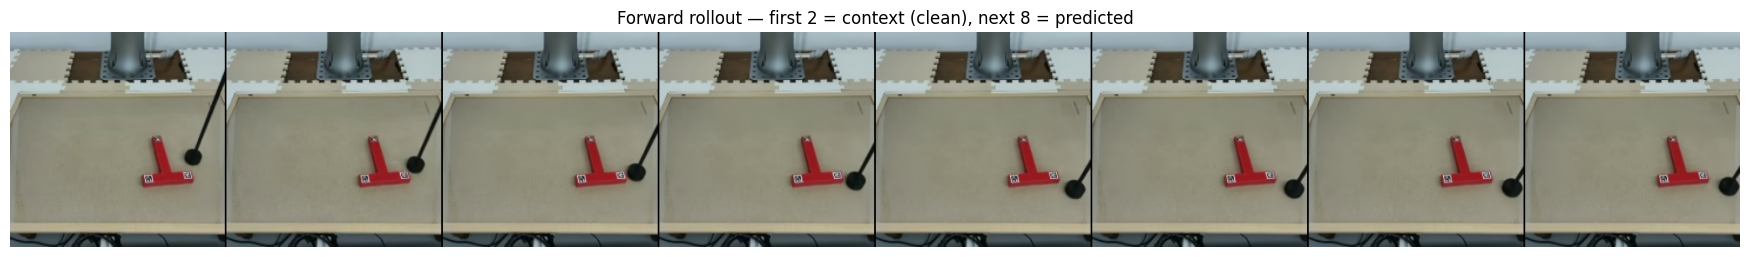

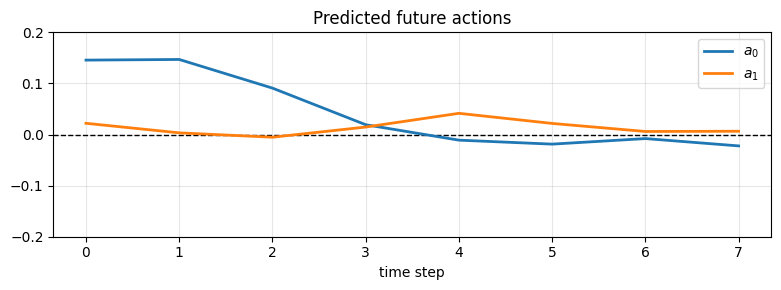

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import mediapy


def plotSnapshots(video, n_frames=8, border_width=2, figsize=None, title=None):
    """Evenly-spaced frames as a single horizontal strip, with black separators."""
    T = video.shape[0]
    indices = np.linspace(0, T - 1, n_frames, dtype=int)
    frames = video[indices].cpu().permute(0, 2, 3, 1).to(torch.float32).numpy()
    frames = np.clip(frames * 255, 0, 255).astype(np.uint8)
    H, _, C = frames.shape[1], frames.shape[2], frames.shape[3]
    border = np.zeros((H, border_width, C), dtype=np.uint8)
    parts = []
    for i, f in enumerate(frames):
        if i > 0:
            parts.append(border)
        parts.append(f)
    strip = np.concatenate(parts, axis=1)
    fig, ax = plt.subplots(1, 1, figsize=figsize or (n_frames * 2.2, 2.6))
    ax.imshow(strip)
    if title:
        ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


def plotActions(actions, title=None, figsize=(8, 3)):
    act = actions.cpu().float().numpy() if hasattr(actions, 'cpu') else np.array(actions)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    for i in range(act.shape[-1]):
        ax.plot(act[:, i], linewidth=2, label=fr'$a_{i}$')
    ax.set_xlabel('time step')
    ax.set_ylim(-0.2, 0.2)
    if title:
        ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plotVideo(video, fps=10):
    arr = (video.cpu().permute(0, 2, 3, 1).to(torch.float32).numpy() * 255).astype('uint8')
    mediapy.show_video(arr, fps=fps)


# Decode: clean context frames + predicted future from the rollout (batch elem 0)
with torch.no_grad():
    full_latents = torch.cat([ctx_latents[:1], pred_obs[:1]], dim=1)
    img_full = tokenizer.decode(full_latents)[0].clamp(0, 1)

# 1) Rollout snapshots — first T_CTX frames are clean context, the rest are predicted
plotSnapshots(
    img_full, n_frames=min(8, T_CTX + NUM_PRED_STEPS),
    title=f'Forward rollout — first {T_CTX} = context (clean), next {NUM_PRED_STEPS} = predicted',
)

# 2) Inline video of context + predicted future
plotVideo(img_full)

# 3) Predicted future-action trajectory
plotActions(pred_act[0], title='Predicted future actions')

## Discrete adjoint backward

Walk the saved trajectory from $k = N-1$ down to $0$. At each step:

1. Recompute the denoiser forward at the saved $(z_{\text{fut}, k}, a_{\text{fut}, k})$ with `requires_grad=True` on the *inputs only*.
2. One VJP yields gradients wrt both the inputs (state cotangent update) and the parameters (per-step contribution).
3. Apply $\lambda_k = (1-\alpha_k)\lambda_{k+1} + \alpha_k J^{\!T} \lambda_{k+1}$ — both modalities updated in one call because the denoiser couples obs↔act.

Memory: only the saved trajectory $\{U_k\}$ + one set of activations at a time. *No* growth in $N$.

In [9]:
def adjoint_policy_grad(traj_z, traj_a, setup, loss_fn):
    # terminal cotangent  λ_N = ∂L/∂U_N
    z_N = traj_z[-1].detach().clone().requires_grad_(True)
    a_N = traj_a[-1].detach().clone().requires_grad_(True)
    L = loss_fn(z_N, a_N)
    lam_z, lam_a = torch.autograd.grad(L, [z_N, a_N], allow_unused=True)
    if lam_z is None: lam_z = torch.zeros_like(z_N)
    if lam_a is None: lam_a = torch.zeros_like(a_N)

    params = list(denoiser.parameters())
    grads = [torch.zeros_like(p) for p in params]

    alphas = setup["alphas"]
    for k in reversed(range(len(alphas))):
        alpha = alphas[k]
        z_in = traj_z[k].detach().clone().requires_grad_(True)
        a_in = traj_a[k].detach().clone().requires_grad_(True)

        z_hat_fut, a_hat_fut = denoiser_call(z_in, a_in, setup, k)

        out = torch.autograd.grad(
            [z_hat_fut, a_hat_fut],
            [z_in, a_in] + params,
            grad_outputs=[alpha * lam_z, alpha * lam_a],
            allow_unused=True,
        )
        grad_z_in, grad_a_in = out[0], out[1]
        grad_params = out[2:]

        # state cotangent: λ_k = (1-α) λ_{k+1} + α J^T λ_{k+1}
        lam_z = (1.0 - alpha) * lam_z + (grad_z_in if grad_z_in is not None else 0)
        lam_a = (1.0 - alpha) * lam_a + (grad_a_in if grad_a_in is not None else 0)

        # accumulate parameter gradient
        for g, gp in zip(grads, grad_params):
            if gp is not None:
                g.add_(gp)

    return grads


t0 = time.time()
grads_adj = adjoint_policy_grad(traj_z, traj_a, setup, terminal_loss)
torch.cuda.synchronize()
print(f"adjoint backward: {time.time() - t0:.2f}s")
print(f"max |grad|: {max(g.abs().max().item() for g in grads_adj):.3e}")

adjoint backward: 1.06s
max |grad|: 4.805e-02


## Verification: autograd through the rollout

Same forward, but with autograd enabled — the activation cache from all $N$ denoiser passes lives in memory until backward. Should match the adjoint to ~`1e-6` in fp32.

In [10]:
def autograd_policy_grad(setup, loss_fn):
    z_fut = setup["z_fut0"].clone()
    a_fut = setup["a_fut0"].clone()
    for k, alpha in enumerate(setup["alphas"]):
        z_hat_fut, a_hat_fut = denoiser_call(z_fut, a_fut, setup, k)
        z_fut = z_fut + alpha * (z_hat_fut - z_fut)
        a_fut = a_fut + alpha * (a_hat_fut - a_fut)
    L = loss_fn(z_fut, a_fut)
    g = torch.autograd.grad(L, list(denoiser.parameters()), allow_unused=True)
    return [gi if gi is not None else torch.zeros_like(p)
            for gi, p in zip(g, denoiser.parameters())], L.item()


t0 = time.time()
grads_naive, L_naive = autograd_policy_grad(setup, terminal_loss)
torch.cuda.synchronize()
print(f"autograd-through-rollout: {time.time() - t0:.2f}s")
print(f"L (autograd) = {L_naive:.6f}   L (forward) = {L:.6f}")

autograd-through-rollout: 1.06s
L (autograd) = 0.003651   L (forward) = 0.003651


In [10]:
items = []
for (name, p), ga, gn in zip(denoiser.named_parameters(), grads_adj, grads_naive):
    if gn.abs().max().item() == 0 and ga.abs().max().item() == 0:
        continue
    diff = (ga - gn).abs().max().item()
    nrm = gn.abs().max().item()
    rel = diff / max(nrm, 1e-12)
    items.append((nrm, name, diff, rel))
items.sort(reverse=True)

print(f"{'param':50s}  {'|grad|max':>10s}  {'|adj-naive|':>11s}  {'rel err':>10s}")
print("-" * 88)
for nrm, name, diff, rel in items[:10]:
    print(f"{name:50s}  {nrm:10.2e}  {diff:11.2e}  {rel:10.2e}")
print(f"\n{len(items)}/{len(grads_adj)} parameter tensors received non-zero gradient")
print(f"Worst relative error: {max(it[3] for it in items):.2e}")

param                                                |grad|max  |adj-naive|     rel err
----------------------------------------------------------------------------------------
model.action_projector.weight                         3.93e-01     9.31e-10    2.37e-09
model.obs_projector.weight                            5.61e-02     2.61e-08    4.64e-07
model.action_projector.bias                           2.81e-02     0.00e+00    0.00e+00
model.layers.0.layers.2.norm1.weight                  2.41e-02     1.12e-08    4.63e-07
model.layers.0.layers.2.attn.attn.W_v.weight          2.29e-02     9.72e-09    4.25e-07
model.layers.0.layers.0.ffn.gate.weight               2.10e-02     9.31e-09    4.44e-07
model.layers.1.layers.0.attn.attn.W_v.weight          1.95e-02     6.52e-09    3.34e-07
model.layers.2.layers.2.attn.attn.W_q.weight          1.71e-02     5.68e-09    3.31e-07
model.layers.2.layers.1.norm2.weight                  1.69e-02     2.24e-08    1.33e-06
model.layers.2.layers.0.attn.at

## Section 2 — Augmented adjoint for $\log \pi_\theta$

Same recipe as Section 1 but the integrated state is augmented with a scalar $\ell$:
$$\dot \ell \;=\; -\nabla_U\!\cdot v_\theta(U, \tau, c), \qquad \ell_0 = \log p_0(U_0),$$
so $\ell_N = \log \pi_\theta(U_N)$ (instantaneous change-of-variables along the flow). The discrete recurrence on $\mu$ acquires a $\nabla_U d_\theta$ forcing term and the parameter gradient picks up a $-\partial d_\theta/\partial \theta$ contribution; $\nu \equiv 1$ exactly as in `adjoint_toy.ipynb` Section 2.

**Velocity.** The Euler step here is $U_{k+1} = U_k + \alpha_k(\widehat U_\theta - U_k)$ with $\alpha_k = \Delta\tau/(1-\tau_k)$, i.e. velocity $v_\theta = (\widehat U_\theta - U)/(1 - \tau)$. The Hutchinson divergence estimator is therefore
$$d_\theta(U; \xi) \;=\; \xi^\top J_{v_\theta}\, \xi \;=\; \frac{1}{1-\tau}\bigl(\xi^\top J_{\widehat U}\, \xi \;-\; \|\xi\|^2\bigr), \qquad \xi \sim \mathcal{N}(0, I).$$
One VJP per step replaces an $\sim$8k-dimension trace.

**Verification trick.** With Hutchinson, the gradient *is* stochastic — even an autograd-through-augmented-forward gives a different stochastic estimate. To verify the **adjoint code** (not Hutchinson itself), we share the noise sequence $\{\xi_k\}$ between adjoint and autograd. Both then compute the gradient of the *same* objective $\mathcal{L}_\xi(\theta)$ and should match to fp32 precision. We then run a separate **Monte-Carlo variance check** across independent $\xi$-seeds to see how noisy the Hutchinson estimator actually is on this network.

**Memory note.** Both sides need second-order autograd through the denoiser. PyTorch's Flash / mem-efficient SDPA kernels lack double-backward, so we switch to the math kernel. The math kernel + create-graph through the rollout is much heavier than Section 1, so we drop to `NUM_PRED_STEPS=1, NUM_DIFFUSION_STEPS=2` for the autograd verification (the adjoint itself is flat in $N$).

In [ ]:
# Switch to math SDPA — Flash / mem-efficient kernels have no double-backward.
torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)
torch.backends.cuda.enable_math_sdp(True)

NUM_PRED_STEPS_AUG = 1
NUM_DIFFUSION_STEPS_AUG = 2

traj_z_aug, traj_a_aug, setup_aug = policy_forward_with_traj(
    ctx_latents, ctx_actions, NUM_PRED_STEPS_AUG, NUM_DIFFUSION_STEPS_AUG
)


def make_xi_seq(setup, generator):
    """Sample (xi_z, xi_a) per diffusion step using the given generator."""
    z_shape = setup["z_fut0"].shape; a_shape = setup["a_fut0"].shape
    dev, dt = setup["z_fut0"].device, setup["z_fut0"].dtype
    return [(torch.randn(z_shape, device=dev, dtype=dt, generator=generator),
             torch.randn(a_shape, device=dev, dtype=dt, generator=generator))
            for _ in range(len(setup["alphas"]))]


state_dim = setup_aug['z_fut0'][0].numel() + setup_aug['a_fut0'][0].numel()
print(f"state dim: {state_dim} (per batch element)")
print(f"alphas (aug): {setup_aug['alphas']}")

In [ ]:
def adjoint_aug_grad(traj_z, traj_a, setup, xi_seq):
    """d log pi(U_N) / d theta via the augmented adjoint with Hutchinson."""
    B = traj_z[0].shape[0]
    dev, dt0 = traj_z[0].device, traj_z[0].dtype
    mu_z = torch.zeros_like(traj_z[0])
    mu_a = torch.zeros_like(traj_a[0])
    nu = torch.ones(B, device=dev, dtype=dt0)
    params = list(denoiser.parameters())
    grads = [torch.zeros_like(p) for p in params]
    step_size = 1.0 / len(setup["alphas"])

    for k in reversed(range(len(setup["alphas"]))):
        alpha = setup["alphas"][k]
        tau = 1.0 - step_size / alpha            # invert α_k = Δτ/(1-τ_k)
        xi_z, xi_a = xi_seq[k]

        # ----- (1) Uhat-VJP: cotangent α * μ_{k+1} -----
        z_in = traj_z[k].detach().clone().requires_grad_(True)
        a_in = traj_a[k].detach().clone().requires_grad_(True)
        z_hat, a_hat = denoiser_call(z_in, a_in, setup, k)
        out_v = torch.autograd.grad(
            [z_hat, a_hat], [z_in, a_in] + params,
            grad_outputs=[alpha * mu_z, alpha * mu_a],
            allow_unused=True,
        )
        ga_v_z, ga_v_a, *gp_v = out_v

        # ----- (2) divergence-VJP: cotangent (-Δτ * ν) on d_θ -----
        z_in2 = traj_z[k].detach().clone().requires_grad_(True)
        a_in2 = traj_a[k].detach().clone().requires_grad_(True)
        z_hat2, a_hat2 = denoiser_call(z_in2, a_in2, setup, k)
        # inner VJP for ξ^T J_Uhat (must keep a graph for the outer grad)
        g_z, g_a = torch.autograd.grad(
            [z_hat2, a_hat2], [z_in2, a_in2],
            grad_outputs=[xi_z, xi_a],
            create_graph=True, retain_graph=True,
        )
        # ξ^T J_Uhat ξ minus |ξ|^2, scaled by 1/(1-τ)
        score = (g_z * xi_z).sum(dim=tuple(range(1, g_z.ndim))) \
              + (g_a * xi_a).sum(dim=tuple(range(1, g_a.ndim)))
        xi_norm_sq = (xi_z**2).sum(dim=tuple(range(1, xi_z.ndim))) \
                   + (xi_a**2).sum(dim=tuple(range(1, xi_a.ndim)))
        d_theta = (score - xi_norm_sq) / (1.0 - tau)
        cot_d = -step_size * nu                     # (B,)
        out_d = torch.autograd.grad(
            d_theta, [z_in2, a_in2] + params,
            grad_outputs=cot_d, allow_unused=True,
        )
        ga_d_z, ga_d_a, *gp_d = out_d

        # μ_k = (1-α) μ_{k+1} + α J_Uhat^T μ_{k+1} - Δτ (∇_U d_θ) ν_{k+1}
        mu_z = (1 - alpha) * mu_z \
             + (ga_v_z if ga_v_z is not None else 0) \
             + (ga_d_z if ga_d_z is not None else 0)
        mu_a = (1 - alpha) * mu_a \
             + (ga_v_a if ga_v_a is not None else 0) \
             + (ga_d_a if ga_d_a is not None else 0)

        for g, gv, gd in zip(grads, gp_v, gp_d):
            if gv is not None: g.add_(gv)
            if gd is not None: g.add_(gd)
    return grads

In [ ]:
def autograd_aug_grad(setup, xi_seq):
    """Ground truth: autograd through the augmented forward, using the SAME ξ_seq."""
    z = setup["z_fut0"].detach().clone().requires_grad_(True)
    a = setup["a_fut0"].detach().clone().requires_grad_(True)
    log_pi = torch.zeros(z.shape[0], device=z.device, dtype=z.dtype)
    step_size = 1.0 / len(setup["alphas"])

    for k, alpha in enumerate(setup["alphas"]):
        tau = 1.0 - step_size / alpha
        xi_z, xi_a = xi_seq[k]
        z_hat, a_hat = denoiser_call(z, a, setup, k)
        # Hutchinson divergence with create_graph so the outer autograd can chain through
        g_z, g_a = torch.autograd.grad(
            [z_hat, a_hat], [z, a], grad_outputs=[xi_z, xi_a],
            create_graph=True, retain_graph=True,
        )
        score = (g_z * xi_z).sum(dim=tuple(range(1, g_z.ndim))) \
              + (g_a * xi_a).sum(dim=tuple(range(1, g_a.ndim)))
        xi_norm_sq = (xi_z**2).sum(dim=tuple(range(1, xi_z.ndim))) \
                   + (xi_a**2).sum(dim=tuple(range(1, xi_a.ndim)))
        d_theta = (score - xi_norm_sq) / (1.0 - tau)
        log_pi = log_pi - step_size * d_theta
        z = z + alpha * (z_hat - z)
        a = a + alpha * (a_hat - a)

    L = log_pi.sum()
    g = torch.autograd.grad(L, list(denoiser.parameters()), allow_unused=True)
    return [gi if gi is not None else torch.zeros_like(p)
            for gi, p in zip(g, denoiser.parameters())], L.item()


# Shared ξ for the verification
gen_verify = torch.Generator(device=device).manual_seed(7)
xi_seq_v = make_xi_seq(setup_aug, gen_verify)

torch.cuda.synchronize(); t0 = time.time()
grads_aug_adj = adjoint_aug_grad(traj_z_aug, traj_a_aug, setup_aug, xi_seq_v)
torch.cuda.synchronize(); print(f"adjoint:    {time.time()-t0:.1f}s")

torch.cuda.synchronize(); t0 = time.time()
grads_aug_naive, L_aug = autograd_aug_grad(setup_aug, xi_seq_v)
torch.cuda.synchronize(); print(f"autograd:   {time.time()-t0:.1f}s")
print(f"L_xi (autograd) = {L_aug:.4f}")

items = []
for (name, p), ga, gn in zip(denoiser.named_parameters(), grads_aug_adj, grads_aug_naive):
    if gn.abs().max().item() == 0 and ga.abs().max().item() == 0: continue
    diff = (ga - gn).abs().max().item()
    nrm = gn.abs().max().item()
    items.append((nrm, name, diff, diff / max(nrm, 1e-12)))
items.sort(reverse=True)
print(f"\n{'param':50s}  {'|grad|max':>10s}  {'|adj-naive|':>11s}  {'rel err':>10s}")
print("-" * 88)
for nrm, name, diff, rel in items[:8]:
    print(f"{name:50s}  {nrm:10.2e}  {diff:11.2e}  {rel:10.2e}")
print(f"\n{len(items)}/{len(grads_aug_adj)} params got non-zero grad. Worst rel err: {max(it[3] for it in items):.2e}")

### Monte-Carlo variance over independent $\xi$ seeds

The verification above only checks that the adjoint code computes the gradient of $\mathcal{L}_\xi$ correctly. The *practical* question is how noisy the Hutchinson estimator is on this particular network: across independent $\xi$ draws, how stable are the gradient norm and direction?

We sample $K=8$ independent $\xi$-sequences and compute the adjoint gradient for each. Three diagnostics:

- **CV of $\lVert g\rVert$** — coefficient of variation of the gradient magnitude.
- **Pairwise $\cos(g_i, g_j)$** — direction agreement between independent samples.
- **$\cos(g_i, \bar g)$** — direction agreement between a single sample and the $K$-sample average; values close to 1 mean a single Hutchinson sample is already a good direction estimator.

In [ ]:
import numpy as np

K = 8
grad_norms = []
flat_grads_cpu = []           # store on CPU in fp16 to fit K copies of 172M params
for k in range(K):
    gen_k = torch.Generator(device=device).manual_seed(100 + k)
    xi_k = make_xi_seq(setup_aug, gen_k)
    g_k = adjoint_aug_grad(traj_z_aug, traj_a_aug, setup_aug, xi_k)
    flat = torch.cat([gi.flatten() for gi in g_k])
    grad_norms.append(flat.norm().item())
    flat_grads_cpu.append(flat.to(dtype=torch.float16, device="cpu"))
    del flat, g_k, xi_k
    torch.cuda.empty_cache()
    print(f"  seed {100+k}: ||grad|| = {grad_norms[-1]:.3e}")

norms = np.array(grad_norms)
print(f"\n||grad|| : mean={norms.mean():.3e}  std={norms.std():.3e}  CV={norms.std()/norms.mean():.3f}")


def _cos(a, b):
    a32, b32 = a.to(torch.float32), b.to(torch.float32)
    return (a32 @ b32).item() / (a32.norm().item() * b32.norm().item())


pairwise = np.array([_cos(flat_grads_cpu[i], flat_grads_cpu[j])
                     for i in range(K) for j in range(i+1, K)])
print(f"pairwise : cos(g_i, g_j) mean={pairwise.mean():.3f}  std={pairwise.std():.3f}  range=[{pairwise.min():.3f}, {pairwise.max():.3f}]")

mean_grad = torch.zeros(flat_grads_cpu[0].shape[0], dtype=torch.float32)
for fg in flat_grads_cpu:
    mean_grad += fg.to(torch.float32) / K
single_to_mean = [_cos(fg, mean_grad.to(torch.float16)) for fg in flat_grads_cpu]
print(f"vs K-avg : cos(g_i, ḡ)  mean={np.mean(single_to_mean):.3f}  (1.0 ⇒ single Hutchinson sample = mean direction)")

## Training loop demo — adjoint gradient drives `terminal_loss` down

200-step Adam loop wired to `adjoint_policy_grad` (Section 1) with the same `terminal_loss = ½·mean(a²)`. Each step re-samples a fresh initial noise via `policy_setup` so the optimiser sees a distribution of rollouts rather than a single fixed point, runs the saved-trajectory forward, computes the per-parameter gradient through the discrete adjoint, copies it into `p.grad`, and steps Adam. After 200 updates we re-run the Section 1 forward and re-render the rollout snapshots / video / action plot — the predicted-action magnitude should be visibly squashed toward zero (the loss minimum), confirming the adjoint gradient is the *right* gradient for actually moving the network.

**Note.** This mutates the denoiser weights in place; we snapshot `denoiser_state_pretrained` first so you can `denoiser.load_state_dict(denoiser_state_pretrained)` to undo, or simply re-run the load cell at the top of the notebook.

step   1/5  loss=0.000402  (1.4s)
step   2/5  loss=0.000213  (2.8s)
step   3/5  loss=0.000131  (4.2s)
step   4/5  loss=0.000082  (5.6s)
step   5/5  loss=0.000053  (7.0s)

total: 7.1s   loss[0]=0.000402  loss[-1]=0.000053


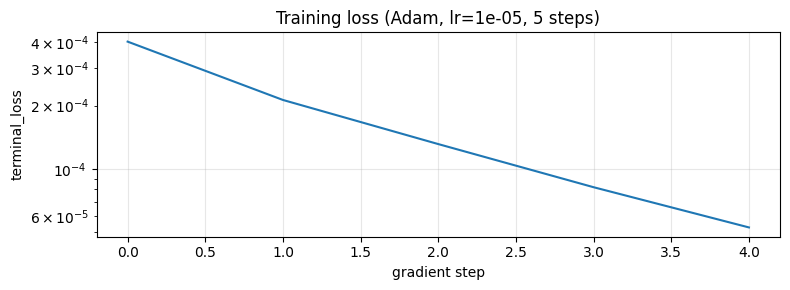

In [10]:
import copy

# Re-enable Flash / efficient SDPA — first-order grads only here, no double-backward needed
torch.backends.cuda.enable_flash_sdp(True)
torch.backends.cuda.enable_mem_efficient_sdp(True)

# Snapshot pretrained weights so the rest of the notebook stays reproducible if you re-run
denoiser_state_pretrained = copy.deepcopy(denoiser.state_dict())

LR = 1e-5
N_TRAIN_STEPS = 5

optimizer = torch.optim.Adam(denoiser.parameters(), lr=LR)
losses = []

t0 = time.time()
for step in range(N_TRAIN_STEPS):
    # Fresh initial noise per step → optimiser sees a distribution of rollouts, not one point
    traj_z_t, traj_a_t, setup_t = policy_forward_with_traj(
        ctx_latents, ctx_actions, NUM_PRED_STEPS, NUM_DIFFUSION_STEPS
    )
    L_step = terminal_loss(traj_z_t[-1], traj_a_t[-1]).item()
    losses.append(L_step)

    grads = adjoint_policy_grad(traj_z_t, traj_a_t, setup_t, terminal_loss)

    optimizer.zero_grad(set_to_none=False)
    for p, g in zip(denoiser.parameters(), grads):
        p.grad = g
    optimizer.step()

    if step == 0 or (step + 1) % 1 == 0:
        print(f"step {step+1:3d}/{N_TRAIN_STEPS}  loss={L_step:.6f}  ({time.time()-t0:.1f}s)")

torch.cuda.synchronize()
print(f"\ntotal: {time.time()-t0:.1f}s   loss[0]={losses[0]:.6f}  loss[-1]={losses[-1]:.6f}")

plt.figure(figsize=(8, 3))
plt.plot(losses, linewidth=1.5)
plt.xlabel('gradient step')
plt.ylabel('terminal_loss')
plt.title(f'Training loss (Adam, lr={LR}, {N_TRAIN_STEPS} steps)')
plt.grid(alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

|a|_mean   pre-train: 0.0362   post-train: 0.0240
terminal_loss   pre-train: 0.000409   post-train: 0.000031


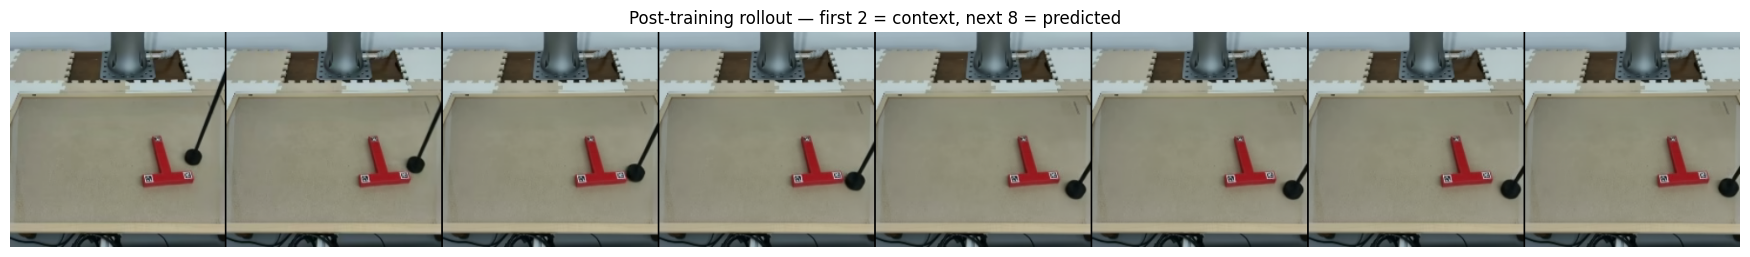

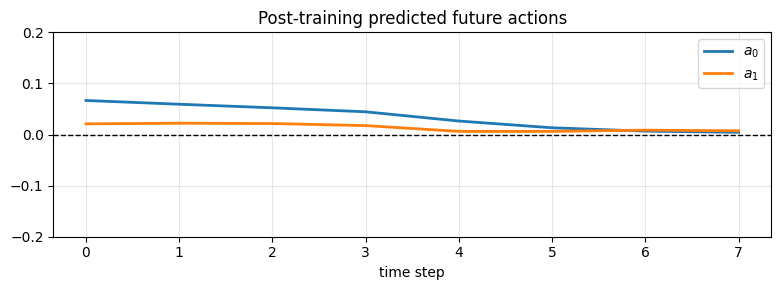

In [13]:
# Post-training inference — same forward as Section 1, now with updated denoiser weights
traj_z_post, traj_a_post, _ = policy_forward_with_traj(
    ctx_latents, ctx_actions, NUM_PRED_STEPS, NUM_DIFFUSION_STEPS
)
pred_obs_post = traj_z_post[-1]
pred_act_post = traj_a_post[-1]

print(f"|a|_mean   pre-train: {pred_act.abs().mean().item():.4f}   "
      f"post-train: {pred_act_post.abs().mean().item():.4f}")
print(f"terminal_loss   pre-train: {L:.6f}   "
      f"post-train: {terminal_loss(pred_obs_post, pred_act_post).item():.6f}")

with torch.no_grad():
    full_latents_post = torch.cat([ctx_latents[:1], pred_obs_post[:1]], dim=1)
    img_full_post = tokenizer.decode(full_latents_post)[0].clamp(0, 1)

plotSnapshots(
    img_full_post, n_frames=min(8, T_CTX + NUM_PRED_STEPS),
    title=f'Post-training rollout — first {T_CTX} = context, next {NUM_PRED_STEPS} = predicted',
)
plotVideo(img_full_post)
plotActions(pred_act_post[0], title='Post-training predicted future actions')

## Notes

**Memory.** Section 1: with `NUM_DIFFUSION_STEPS=4` autograd-through-rollout works because activations from all 4 denoiser passes fit. At `NUM_DIFFUSION_STEPS=8` (the production setting in `sampling.ipynb`) you typically can't backprop through the rollout at full resolution — exactly the case the adjoint solves. Section 2 is much heavier: math SDPA + nested `create_graph` + `2× num_diffusion_steps` denoiser calls per backward step. The adjoint memory footprint is still flat in $N$, but the per-step memory factor is ~3× the terminal-loss case.

**What these gradients are good for.**
- *Reward-weighted fine-tuning* (Section 1) — let $L = -R(\hat o, \hat a)$ for a reward model $R$, plug into an Adam step.
- *Score / log-prob gradient* (Section 2) — building block for path-wise policy-gradient estimators, importance weighting, KL regularisation against a reference policy, etc. The gradient is stochastic via Hutchinson; multiple $\xi$-seeds averaged together drive the variance down (CV ∝ $1/\sqrt{K}$).

**bf16 / autocast.** The original `sampling.ipynb` runs the sampler under `torch.autocast(bfloat16)`. For training-time use of these gradients you can keep autocast on the denoiser forward but accumulate the adjoint cotangents in fp32. The verifications above are fp32 throughout — that's why relative errors land near `1e-6` rather than the `1e-3`–`1e-2` typical of bf16. **Section 2 also requires the math SDPA backend** (`enable_flash_sdp(False)`, `enable_mem_efficient_sdp(False)`) because second-order grads through Flash/efficient attention are not implemented; if you ever want to mix Section 1 (which works with Flash) and Section 2 in the same process, the SDPA-kernel context manager (`torch.nn.attention.sdpa_kernel(SDPBackend.MATH)`) is the cleanest way to scope it.

**Hooks back into the codebase.** Nothing in this notebook modifies `dreamerv4uwm/`. If you want to graduate either helper into a reusable function, the natural home is a sibling of `unified_flowmatching_sampler` in [sampling.py](../dreamerv4uwm/sampling.py): e.g. `policy_sample_and_grad(loss_fn, ...)` for Section 1 and `policy_sample_and_logpi_grad(...)` for Section 2.